In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [25]:
df = pd.read_csv('IPL_Matches_2022.csv')
df.head()

,ID,City,Date,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,WinningTeam,WonBy,Margin,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,29-05-2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,Wickets,7,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,27-05-2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,Rajasthan Royals,Wickets,7,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,25-05-2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,Royal Challengers Bangalore,Runs,14,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,24-05-2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,Gujarat Titans,Wickets,7,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,22-05-2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,Punjab Kings,Wickets,5,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [26]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

duplicate_rows


,ID,City,Date,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,WinningTeam,WonBy,Margin,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2


In [27]:
df.isnull().sum()

ID                 0
City               0
Date               0
MatchNumber        0
Team1              0
Team2              0
Venue              0
TossWinner         0
TossDecision       0
WinningTeam        0
WonBy              0
Margin             0
Player_of_Match    0
Team1Players       0
Team2Players       0
Umpire1            0
Umpire2            0
dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               74 non-null     int64         
 1   City             74 non-null     object        
 2   Date             74 non-null     datetime64[ns]
 3   MatchNumber      74 non-null     object        
 4   Team1            74 non-null     object        
 5   Team2            74 non-null     object        
 6   Venue            74 non-null     object        
 7   TossWinner       74 non-null     object        
 8   TossDecision     74 non-null     object        
 9   WinningTeam      74 non-null     object        
 10  WonBy            74 non-null     object        
 11  Margin           74 non-null     int64         
 12  Player_of_Match  74 non-null     object        
 13  Team1Players     74 non-null     object        
 14  Team2Players     74 non-null     object     

In [30]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [6]:
df

,ID,City,Date,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,WinningTeam,WonBy,Margin,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans,Wickets,7,HH Pandya,"[YBK Jaiswal, JC Buttler, SV Samson, D Padikka...","[WP Saha, Shubman Gill, MS Wade, HH Pandya, DA...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,Rajasthan Royals,Wickets,7,JC Buttler,"[V Kohli, F du Plessis, RM Patidar, GJ Maxwell...","[YBK Jaiswal, JC Buttler, SV Samson, D Padikka...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,Royal Challengers Bangalore,Runs,14,RM Patidar,"[V Kohli, F du Plessis, RM Patidar, GJ Maxwell...","[Q de Kock, KL Rahul, M Vohra, DJ Hooda, MP St...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,Gujarat Titans,Wickets,7,DA Miller,"[YBK Jaiswal, JC Buttler, SV Samson, D Padikka...","[WP Saha, Shubman Gill, MS Wade, HH Pandya, DA...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,Punjab Kings,Wickets,5,Harpreet Brar,"[PK Garg, Abhishek Sharma, RA Tripathi, AK Mar...","[JM Bairstow, S Dhawan, M Shahrukh Khan, MA Ag...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,1304051,Pune,2022-03-29,5,Rajasthan Royals,Sunrisers Hyderabad,"Maharashtra Cricket Association Stadium, Pune",Sunrisers Hyderabad,field,Rajasthan Royals,Runs,61,SV Samson,"[JC Buttler, YBK Jaiswal, SV Samson, D Padikka...","[KS Williamson, Abhishek Sharma, RA Tripathi, ...",BNJ Oxenford,UV Gandhe
70,1304050,Mumbai,2022-03-28,4,Lucknow Super Giants,Gujarat Titans,"Wankhede Stadium, Mumbai",Gujarat Titans,field,Gujarat Titans,Wickets,5,Mohammed Shami,"[KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ H...","[Shubman Gill, MS Wade, V Shankar, HH Pandya, ...",PG Pathak,VK Sharma
71,1304049,Mumbai,2022-03-27,3,Royal Challengers Bangalore,Punjab Kings,"Dr DY Patil Sports Academy, Mumbai",Punjab Kings,field,Punjab Kings,Wickets,5,OF Smith,"[F du Plessis, Anuj Rawat, V Kohli, KD Karthik...","[MA Agarwal, S Dhawan, PBB Rajapaksa, LS Livin...",Nitin Menon,YC Barde
72,1304048,Mumbai,2022-03-27,2,Mumbai Indians,Delhi Capitals,"Brabourne Stadium, Mumbai",Delhi Capitals,field,Delhi Capitals,Wickets,4,Kuldeep Yadav,"[RG Sharma, Ishan Kishan, Anmolpreet Singh, Ti...","[PP Shaw, TL Seifert, Mandeep Singh, RR Pant, ...",RJ Tucker,HAS Khalid


In [10]:
print("Total Matches:", df.shape[0])

Total Matches: 74


In [14]:
print("Teams:", pd.unique(df[['Team1', 'Team2']].values.ravel()))

Teams: ['Rajasthan Royals' 'Gujarat Titans' 'Royal Challengers Bangalore'
 'Lucknow Super Giants' 'Sunrisers Hyderabad' 'Punjab Kings'
 'Delhi Capitals' 'Mumbai Indians' 'Chennai Super Kings'
 'Kolkata Knight Riders']


In [18]:
print("Columns:", df.columns)

Columns: Index(['ID', 'City', 'Date', 'MatchNumber', 'Team1', 'Team2', 'Venue',
       'TossWinner', 'TossDecision', 'WinningTeam', 'WonBy', 'Margin',
       'Player_of_Match', 'Team1Players', 'Team2Players', 'Umpire1',
       'Umpire2'],
      dtype='object')


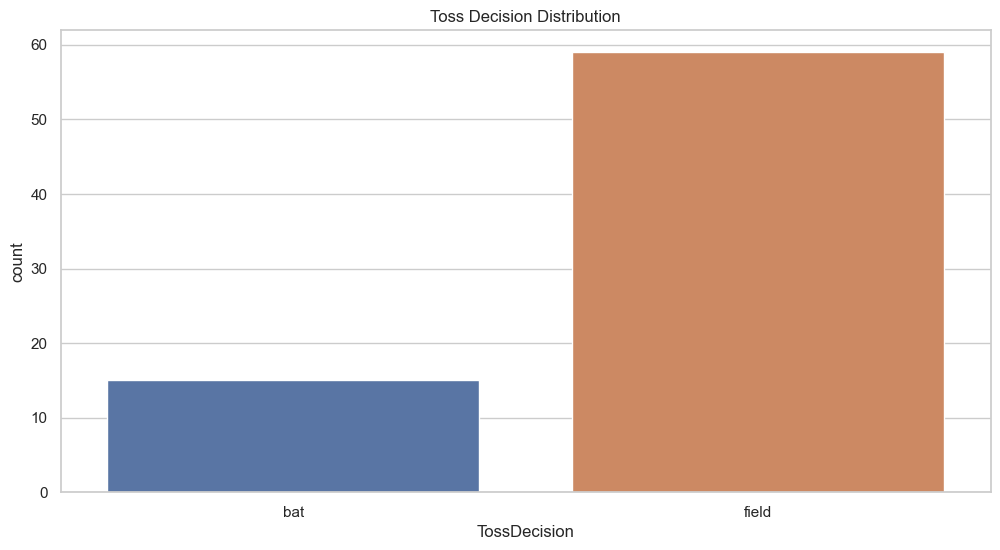

In [12]:
sns.countplot(data=df, x='TossDecision')
plt.title("Toss Decision Distribution")
plt.show()


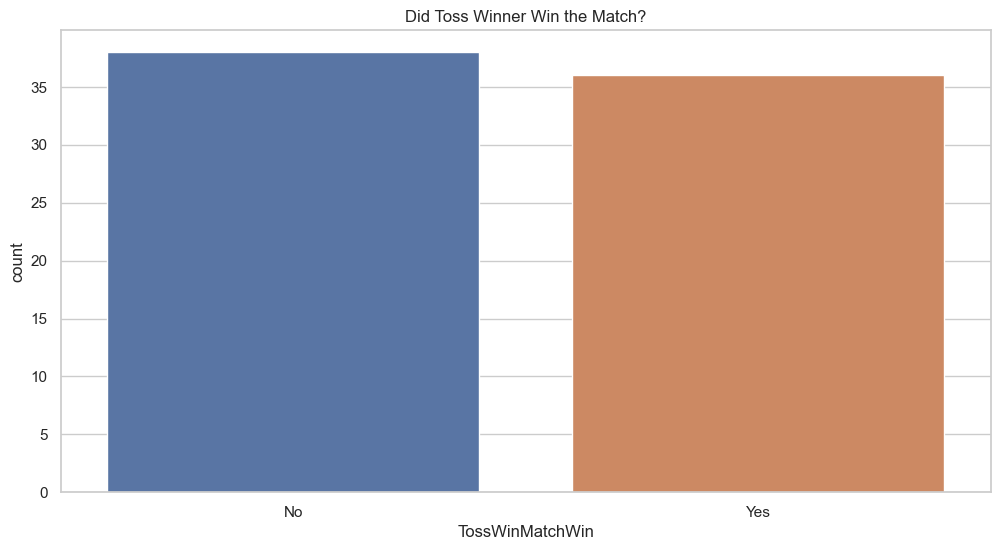

In [13]:
df['TossWinMatchWin'] = df['TossWinner'] == df['WinningTeam']
sns.countplot(data=df, x='TossWinMatchWin')
plt.title("Did Toss Winner Win the Match?")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


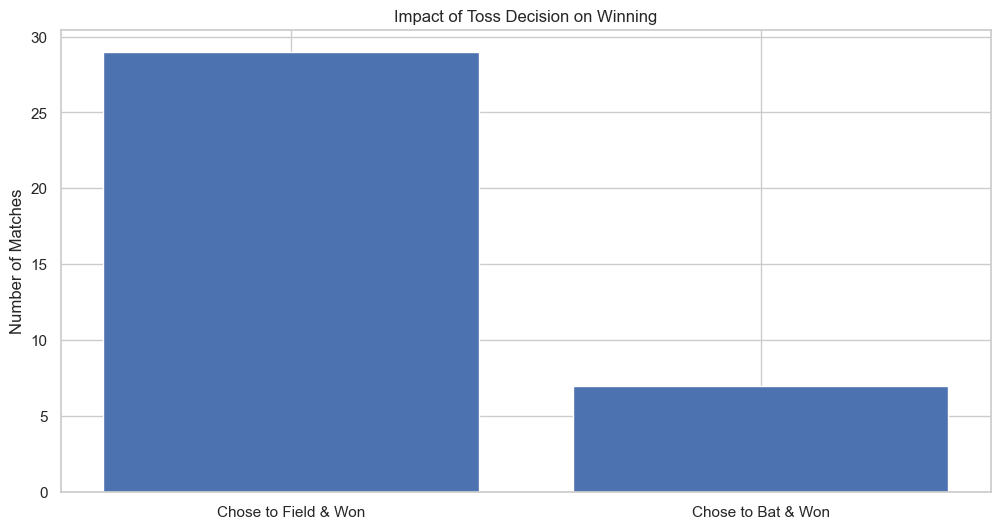

In [26]:
# Fielding = chasing
chasing_wins = df[(df['TossDecision'] == 'field') & (df['TossWinner'] == df['WinningTeam'])].shape[0]
batting_wins = df[(df['TossDecision'] == 'bat') & (df['TossWinner'] == df['WinningTeam'])].shape[0]

plt.bar(['Chose to Field & Won', 'Chose to Bat & Won'], [chasing_wins, batting_wins])
plt.title("Impact of Toss Decision on Winning")
plt.ylabel("Number of Matches")
plt.show()


Venue
Wankhede Stadium, Mumbai                         21
Dr DY Patil Sports Academy, Mumbai               20
Brabourne Stadium, Mumbai                        16
Maharashtra Cricket Association Stadium, Pune    13
Narendra Modi Stadium, Ahmedabad                  2
Eden Gardens, Kolkata                             2
Name: count, dtype: int64


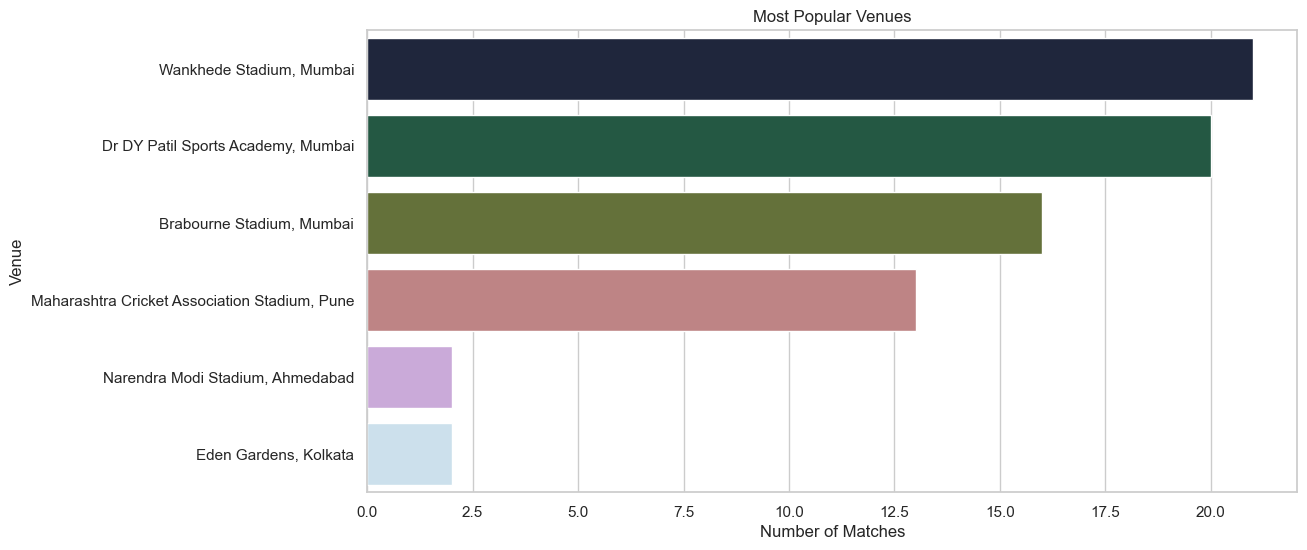

In [29]:
venue_counts = df['Venue'].value_counts().head(10)
print(venue_counts)
sns.barplot(y=venue_counts.index, x=venue_counts.values, palette='cubehelix')
plt.title("Most Popular Venues")
plt.xlabel("Number of Matches")
plt.show()


Player_of_Match
Kuldeep Yadav    4
JC Buttler       3
HH Pandya        2
KL Rahul         2
YS Chahal        2
KD Karthik       2
Avesh Khan       2
PWH de Silva     2
Shubman Gill     2
Umran Malik      2
Name: count, dtype: int64


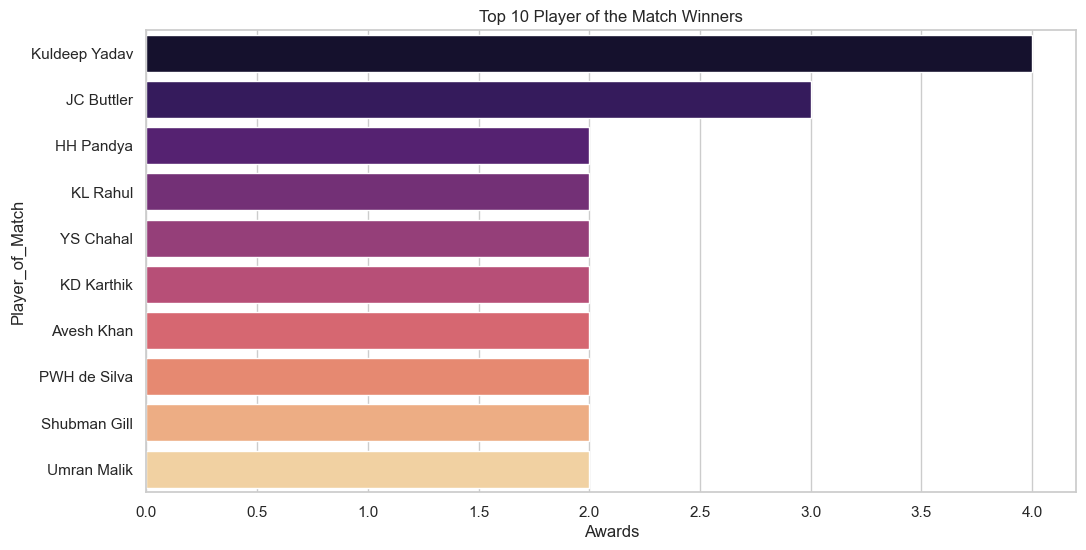

In [31]:
top_players = df['Player_of_Match'].value_counts().head(10)
print(top_players)
sns.barplot(x=top_players.values, y=top_players.index, palette='magma')
plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Awards")
plt.show()


                          Team  Wins
0               Gujarat Titans    12
1             Rajasthan Royals    10
2  Royal Challengers Bangalore     9
3         Lucknow Super Giants     9
4                 Punjab Kings     7
5               Delhi Capitals     7
6          Sunrisers Hyderabad     6
7        Kolkata Knight Riders     6
8               Mumbai Indians     4
9          Chennai Super Kings     4


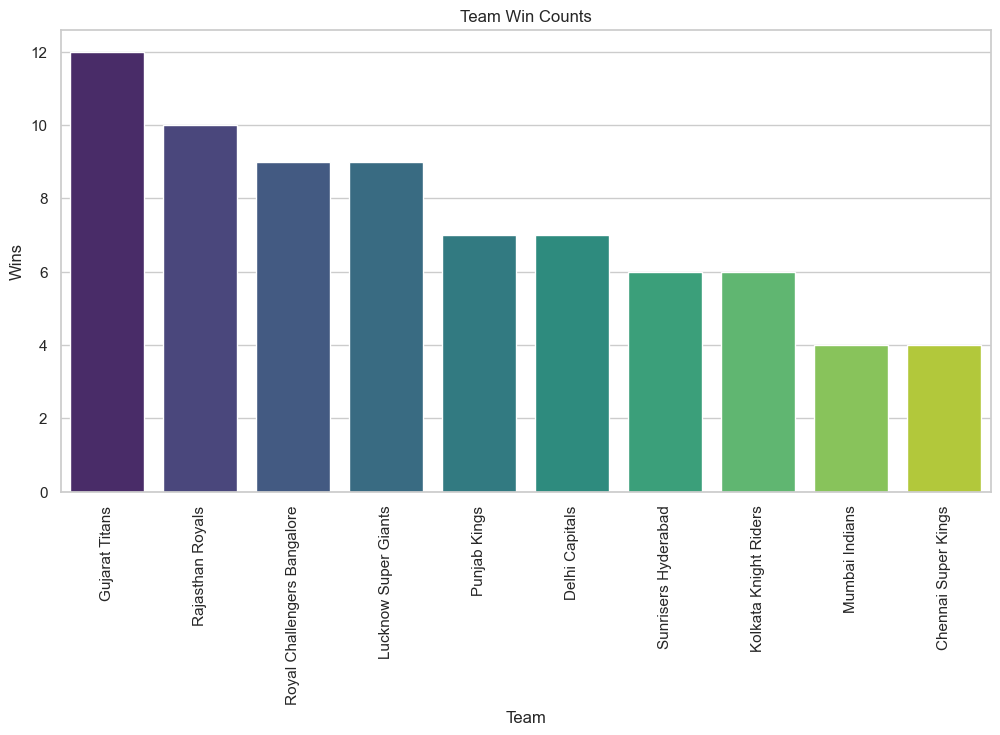

In [15]:
team_wins = df['WinningTeam'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']
print(team_wins)
sns.barplot(data=team_wins, x='Team', y='Wins', palette='viridis')
plt.xticks(rotation=90)
plt.title("Team Win Counts")
plt.show()


In [16]:
# Count matches played
team1_counts = df['Team1'].value_counts()
team2_counts = df['Team2'].value_counts()
matches_played = team1_counts.add(team2_counts, fill_value=0).reset_index()
matches_played.columns = ['Team', 'Matches']
print(matches_played)


                          Team  Matches
0          Chennai Super Kings       14
1               Delhi Capitals       14
2               Gujarat Titans       16
3        Kolkata Knight Riders       14
4         Lucknow Super Giants       15
5               Mumbai Indians       14
6                 Punjab Kings       14
7             Rajasthan Royals       17
8  Royal Challengers Bangalore       16
9          Sunrisers Hyderabad       14


In [17]:
# Count wins
team_wins = df['WinningTeam'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']

# Merge both
team_stats = pd.merge(matches_played, team_wins, on='Team', how='left')
team_stats['Wins'] = team_stats['Wins'].fillna(0).astype(int)
team_stats['Matches'] = team_stats['Matches'].astype(int)

# Sort by Wins
team_stats = team_stats.sort_values(by='Wins', ascending=False).reset_index(drop=True)
print(team_stats)


                          Team  Matches  Wins
0               Gujarat Titans       16    12
1             Rajasthan Royals       17    10
2         Lucknow Super Giants       15     9
3  Royal Challengers Bangalore       16     9
4               Delhi Capitals       14     7
5                 Punjab Kings       14     7
6        Kolkata Knight Riders       14     6
7          Sunrisers Hyderabad       14     6
8          Chennai Super Kings       14     4
9               Mumbai Indians       14     4


In [18]:
# Add win percentage
team_stats['Win %'] = round((team_stats['Wins'] / team_stats['Matches']) * 100, 2)
team_stats.sort_values(by='Win %', ascending=False).reset_index(drop=True)


,Team,Matches,Wins,Win %
0,Gujarat Titans,16,12,75.00
1,Lucknow Super Giants,15,9,60.00
2,Rajasthan Royals,17,10,58.82
3,Royal Challengers Bangalore,16,9,56.25
4,Delhi Capitals,14,7,50.00
5,Punjab Kings,14,7,50.00
6,Kolkata Knight Riders,14,6,42.86
7,Sunrisers Hyderabad,14,6,42.86
8,Chennai Super Kings,14,4,28.57
9,Mumbai Indians,14,4,28.57


In [37]:
df['WinMethod'] = df['WonBy'].apply(lambda x: 'Chasing' if x == 'Wickets' else 'Defending')
df['WinMethod'].value_counts()


WinMethod
Chasing      37
Defending    37
Name: count, dtype: int64

In [38]:
top_players = df['Player_of_Match'].value_counts().reset_index()
top_players.columns = ['Player', 'Awards']
top_players.head(10)


,Player,Awards
0,Kuldeep Yadav,4
1,JC Buttler,3
2,HH Pandya,2
3,KL Rahul,2
4,YS Chahal,2
5,KD Karthik,2
6,Avesh Khan,2
7,PWH de Silva,2
8,Shubman Gill,2
9,Umran Malik,2


In [39]:
df['TossWinMatchWin'] = df['TossWinner'] == df['WinningTeam']
toss_effectiveness = df.groupby('TossDecision')['TossWinMatchWin'].mean().reset_index()
toss_effectiveness.columns = ['TossDecision', 'WinRate']
toss_effectiveness['WinRate'] = (toss_effectiveness['WinRate'] * 100).round(2)
toss_effectiveness


,TossDecision,WinRate
0,bat,46.67
1,field,49.15


In [40]:
umpires = pd.concat([df['Umpire1'], df['Umpire2']])
umpire_counts = umpires.value_counts().reset_index()
umpire_counts.columns = ['Umpire', 'Matches']
umpire_counts.head(5)


,Umpire,Matches
0,Nitin Menon,12
1,CB Gaffaney,11
2,AK Chaudhary,11
3,KN Ananthapadmanabhan,11
4,J Madanagopal,9


In [41]:
matches_per_day = df['Date'].value_counts().reset_index()
matches_per_day.columns = ['Date', 'Matches']
matches_per_day.head(3)


,Date,Matches
0,2022-04-10,2
1,2022-05-15,2
2,2022-04-17,2


In [19]:
# Max win margin By Runs
max_run_win = df[df['WonBy'] == 'Runs'].sort_values(by='Margin', ascending=False).head(1)

# Max win margin By Wickets
max_wicket_win = df[df['WonBy'] == 'Wickets'].sort_values(by='Margin', ascending=False).head(1)

max_run_win[['Date', 'Team1', 'Team2', 'WinningTeam', 'Margin']]


,Date,Team1,Team2,WinningTeam,Margin
19,08-05-2022,Chennai Super Kings,Delhi Capitals,Chennai Super Kings,91


In [20]:
max_wicket_win[['Date', 'Team1', 'Team2', 'WinningTeam', 'Margin']]

,Date,Team1,Team2,WinningTeam,Margin
38,23-04-2022,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,9


In [22]:
# Count toss wins for all teams
toss_wins = df['TossWinner'].value_counts().reset_index()
toss_wins.columns = ['Team', 'TossWins']

# Display the full table sorted by toss wins descending
print(toss_wins.sort_values(by='TossWins', ascending=False).reset_index(drop=True))


                          Team  TossWins
0               Gujarat Titans        10
1          Sunrisers Hyderabad        10
2               Mumbai Indians         9
3        Kolkata Knight Riders         8
4  Royal Challengers Bangalore         8
5               Delhi Capitals         8
6         Lucknow Super Giants         7
7          Chennai Super Kings         6
8             Rajasthan Royals         4
9                 Punjab Kings         4


In [21]:
# Identify if team won after losing the toss
df['WonAfterLosingToss'] = df['WinningTeam'] != df['TossWinner']

# Count wins by each team where they lost the toss
wins_after_losing_toss = df[df['WonAfterLosingToss']].groupby('WinningTeam').size().reset_index(name='WinsAfterLosingToss')
wins_after_losing_toss.sort_values(by='WinsAfterLosingToss', ascending=False)


,WinningTeam,WinsAfterLosingToss
7,Rajasthan Royals,8
6,Punjab Kings,6
2,Gujarat Titans,5
4,Lucknow Super Giants,5
8,Royal Challengers Bangalore,5
0,Chennai Super Kings,3
1,Delhi Capitals,3
3,Kolkata Knight Riders,1
5,Mumbai Indians,1
9,Sunrisers Hyderabad,1
